# Berlin Airbnb Price Analysis

## Objective
This project analyzes Airbnb listings in Berlin to understand:
- How prices vary across neighborhoods  
- Differences between room types  
- Overall price distribution  

## Context
This project uses real-world Airbnb data to explore how location and property type influence pricing patterns in Berlin.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt


##  Data Loading

In [34]:
df = pd.read_csv("listings.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,150,2025-08-09,0.76,1,140,2,First name and Last name: Nicolas Krotz <br/> ...
1,9991,Geourgeous flat - outstanding views,33852,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,135.0,6,7,2020-01-04,0.06,1,241,0,03/Z/RA/003410-18
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,75.0,150,26,2023-11-30,0.14,4,168,0,NaN
3,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,32.0,93,298,2025-09-02,1.57,1,72,1,NaN
4,20858,Designer Loft in Berlin Mitte,71331,Marc,Pankow,Prenzlauer Berg Südwest,52.53711,13.40888,Entire home/apt,202.0,3,140,2025-07-16,0.89,1,253,4,03/Z/RA/009767-24


In [35]:
df.shape

(14274, 18)

In [36]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14274 non-null  int64  
 1   name                            14274 non-null  object 
 2   host_id                         14274 non-null  int64  
 3   host_name                       14260 non-null  object 
 4   neighbourhood_group             14274 non-null  object 
 5   neighbourhood                   14274 non-null  object 
 6   latitude                        14274 non-null  float64
 7   longitude                       14274 non-null  float64
 8   room_type                       14274 non-null  object 
 9   price                           9264 non-null   float64
 10  minimum_nights                  14274 non-null  int64  
 11  number_of_reviews               14274 non-null  int64  
 12  last_review                     

## Data Cleaning

- Convert price column to numeric
- Handle missing values

In [38]:
# Clean price column
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# Drop missing values
df = df.dropna(subset=['price', 'neighbourhood'])

df[['price', 'neighbourhood']].head()

,price,neighbourhood
0,105.0,Prenzlauer Berg Südwest
1,135.0,Prenzlauer Berg Südwest
2,75.0,Prenzlauer Berg Nordwest
3,32.0,Reuterstraße
4,202.0,Prenzlauer Berg Südwest


## Price Analysis Analysis

In [39]:
avg_price_neigh = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
avg_price_neigh.head(10)

,price
neighbourhood,
Marienfelde,1078.250000
Müggelheim,1064.842105
Alexanderplatz,922.402759
Schönholz/Wilhelmsruh/Rosenthal,584.857143
Bohnsdorf,503.041667
Schmöckwitz/Karolinenhof/Rauchfangswerder,443.592593
West 5,381.545455
Blankenfelde/Niederschönhausen,340.619048
Rudow,293.510638


In [40]:
df.groupby('room_type')['price'].mean()

,price
room_type,
Entire home/apt,162.085072
Hotel room,5532.277228
Private room,86.478761
Shared room,71.525773


## Data Visualization

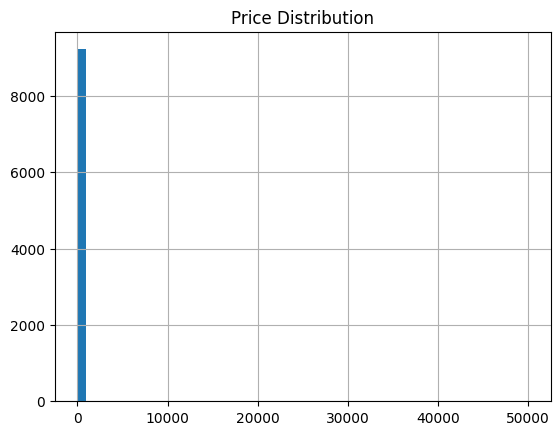

In [41]:
df['price'].hist(bins=50)
plt.title("Price Distribution")
plt.show()

In [42]:
avg_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

top10 = avg_price.head(10)

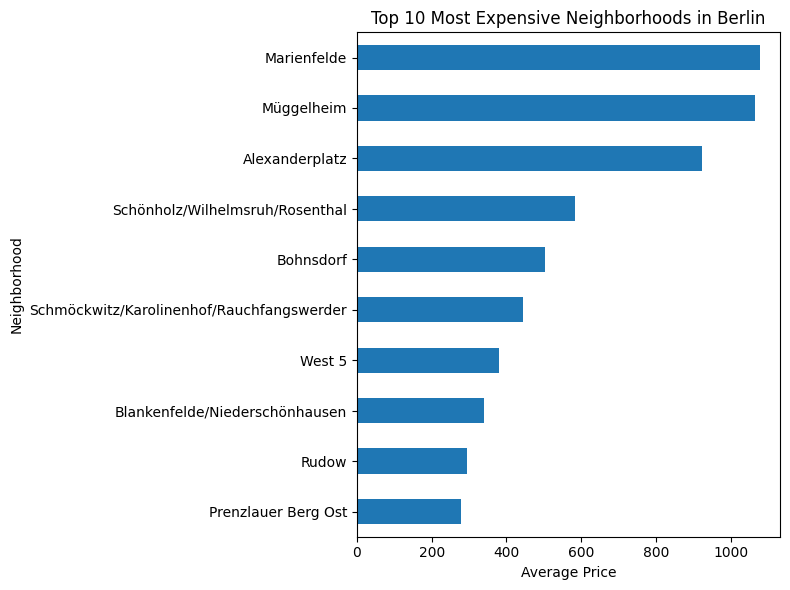

In [43]:
top10 = avg_price.nlargest(10)

top10.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Top 10 Most Expensive Neighborhoods in Berlin")
plt.xlabel("Average Price")
plt.ylabel("Neighborhood")

plt.tight_layout()
plt.show()

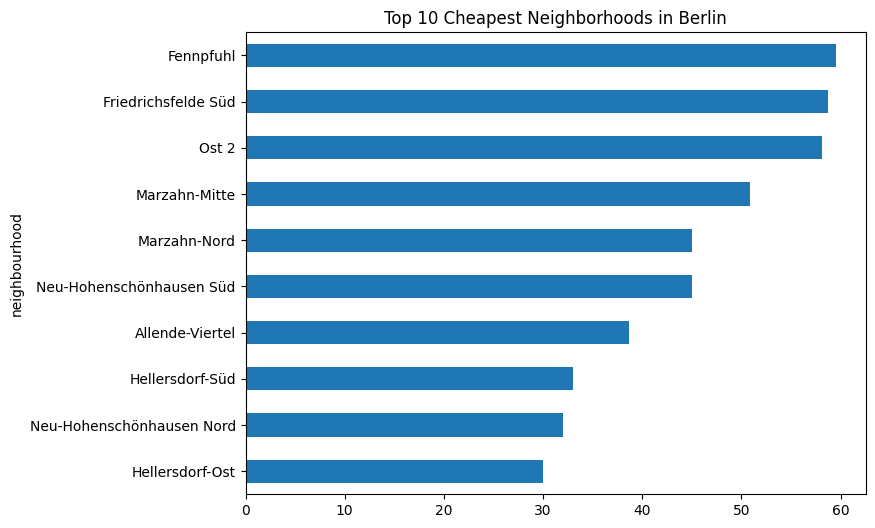

In [44]:
bottom10 = avg_price.tail(10)

bottom10.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Cheapest Neighborhoods in Berlin")
plt.show()

In [45]:
plt.savefig("price_by_neighborhood.png")

<Figure size 640x480 with 0 Axes>

In [46]:
from google.colab import files
files.download("price_by_neighborhood.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Key Insights

- Listings in central Berlin neighborhoods have approximately 2–3x higher average prices compared to outer districts, highlighting strong location-driven demand
- Entire homes command substantially higher prices than private rooms, reflecting different use cases and customer segments  
- After removing extreme outliers, pricing patterns become more consistent and better represent typical listings  
- The price distribution is right-skewed, with a small number of high-priced listings disproportionately affecting the mean  